Index(['Sentence', 'Sentiment'], dtype='object')


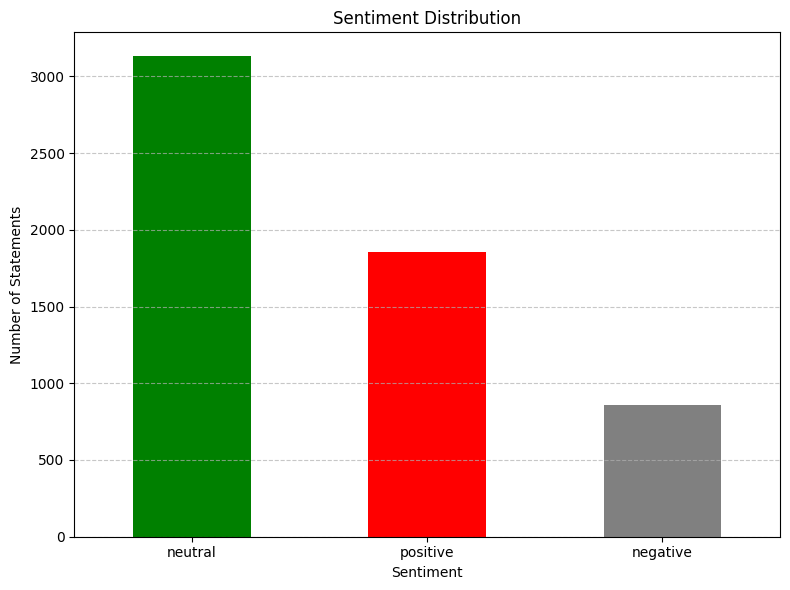

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv('data.csv')

# Clean column names by stripping extra whitespace
df.columns = df.columns.str.strip()

# Just to confirm
print(df.columns)

# Count sentiment categories
sentiment_counts = df['Sentiment'].value_counts()

# Plotting
plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['green', 'red', 'gray'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Statements')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


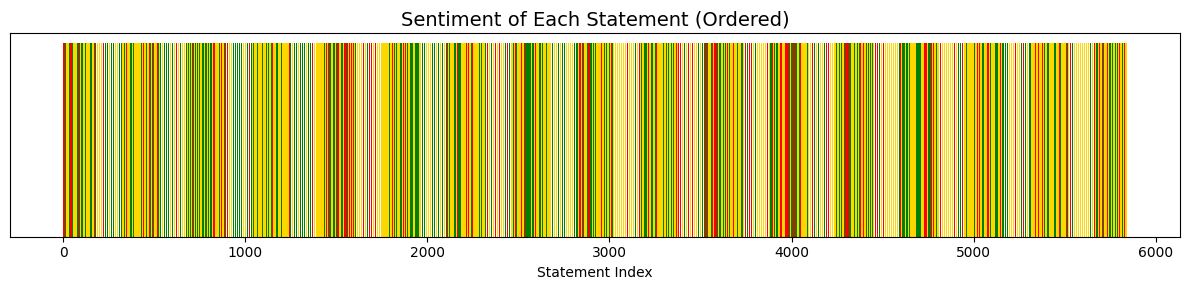

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv('data.csv')
df.columns = df.columns.str.strip()

# Map sentiments to colors
color_map = {
    'positive': 'green',
    'negative': 'red',
    'neutral': 'gold'
}

# Create color list for plotting
colors = df['Sentiment'].map(lambda x: color_map.get(x.strip().lower(), 'gray'))

# Plot as bar chart with tiny bars (one per statement)
plt.figure(figsize=(12, 3))
plt.bar(range(len(df)), [1]*len(df), color=colors, width=0.8)

# Style
plt.title('Sentiment of Each Statement (Ordered)', fontsize=14)
plt.xlabel('Statement Index')
plt.yticks([])  # Hide y-axis ticks since bar height is uniform
plt.grid(False)
plt.tight_layout()
plt.show()


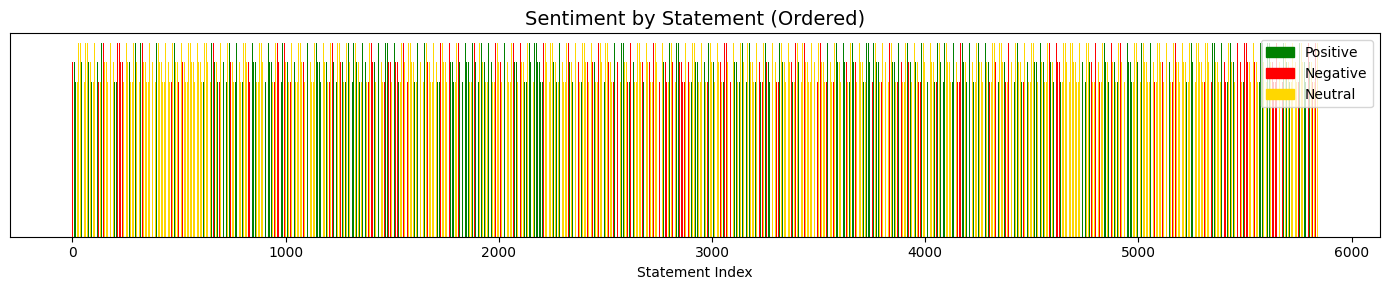

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load CSV
df = pd.read_csv('data.csv')
df.columns = df.columns.str.strip()

# Map sentiments to colors
color_map = {
    'positive': 'green',
    'negative': 'red',
    'neutral': 'gold'
}

# Create color list
colors = df['Sentiment'].map(lambda x: color_map.get(x.strip().lower(), 'gray'))

# Create slight variations in bar height (just for visual effect)
bar_heights = [0.8 + 0.1*(i % 3) for i in range(len(df))]

# Plot
plt.figure(figsize=(14, 3))
plt.bar(range(len(df)), bar_heights, color=colors, width=0.6)

# Title and axis
plt.title('Sentiment by Statement (Ordered)', fontsize=14)
plt.xlabel('Statement Index')
plt.yticks([])  # Hide y-axis ticks for clean look
plt.grid(False)

# Legend
legend_handles = [
    mpatches.Patch(color='green', label='Positive'),
    mpatches.Patch(color='red', label='Negative'),
    mpatches.Patch(color='gold', label='Neutral')
]
plt.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.show()


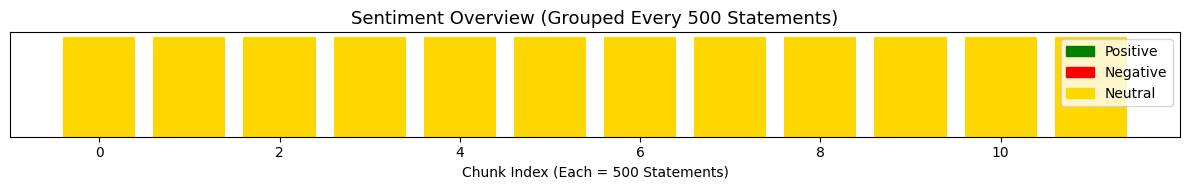

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

# Load and clean data
df = pd.read_csv('data.csv')
df.columns = df.columns.str.strip()

# Chunking function (e.g., every 500 statements)
chunk_size = 500
chunks = [df[i:i+chunk_size] for i in range(0, len(df), chunk_size)]

# Get dominant sentiment per chunk
dominant_sentiments = []
for chunk in chunks:
    counts = Counter(chunk['Sentiment'].str.strip().str.lower())
    dominant = counts.most_common(1)[0][0]
    dominant_sentiments.append(dominant)

# Map to colors
color_map = {
    'positive': 'green',
    'negative': 'red',
    'neutral': 'gold'
}
colors = [color_map.get(sentiment, 'gray') for sentiment in dominant_sentiments]

# Plotting
plt.figure(figsize=(12, 2))
plt.bar(range(len(colors)), [1]*len(colors), color=colors, width=0.8)

# Style
plt.title('Sentiment Overview (Grouped Every 500 Statements)', fontsize=13)
plt.xlabel('Chunk Index (Each = 500 Statements)')
plt.yticks([])
plt.grid(False)

# Legend
legend_handles = [
    mpatches.Patch(color='green', label='Positive'),
    mpatches.Patch(color='red', label='Negative'),
    mpatches.Patch(color='gold', label='Neutral')
]
plt.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.show()


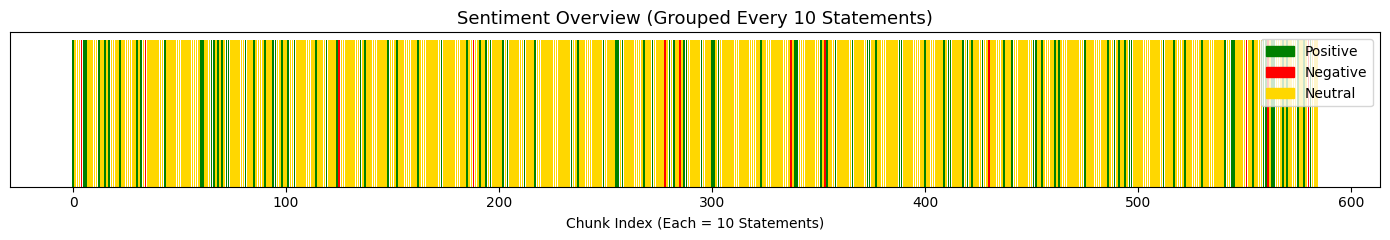

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

# Load and clean data
df = pd.read_csv('data.csv')
df.columns = df.columns.str.strip()

# Chunking every 10 statements
chunk_size = 10
chunks = [df[i:i+chunk_size] for i in range(0, len(df), chunk_size)]

# Get dominant sentiment per chunk
dominant_sentiments = []
for chunk in chunks:
    counts = Counter(chunk['Sentiment'].str.strip().str.lower())
    dominant = counts.most_common(1)[0][0]
    dominant_sentiments.append(dominant)

# Map to colors
color_map = {
    'positive': 'green',
    'negative': 'red',
    'neutral': 'gold'
}
colors = [color_map.get(sentiment, 'gray') for sentiment in dominant_sentiments]

# Plotting
plt.figure(figsize=(14, 2.5))
plt.bar(range(len(colors)), [1]*len(colors), color=colors, width=0.8)

# Style
plt.title('Sentiment Overview (Grouped Every 10 Statements)', fontsize=13)
plt.xlabel('Chunk Index (Each = 10 Statements)')
plt.yticks([])
plt.grid(False)

# Legend
legend_handles = [
    mpatches.Patch(color='green', label='Positive'),
    mpatches.Patch(color='red', label='Negative'),
    mpatches.Patch(color='gold', label='Neutral')
]
plt.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.show()


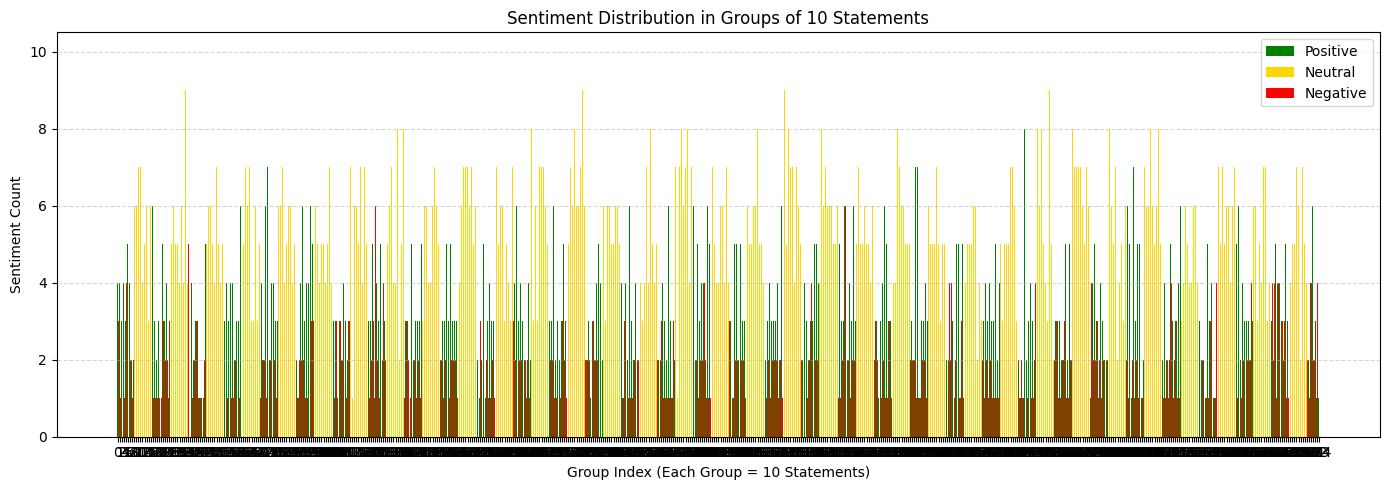

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load and clean
df = pd.read_csv('data.csv')
df.columns = df.columns.str.strip()

# Group every 10 statements
chunk_size = 10
chunks = [df[i:i+chunk_size] for i in range(0, len(df), chunk_size)]

# Count each sentiment in each chunk
positive_counts = []
neutral_counts = []
negative_counts = []

for chunk in chunks:
    sentiments = chunk['Sentiment'].str.strip().str.lower()
    positive_counts.append((sentiments == 'positive').sum())
    neutral_counts.append((sentiments == 'neutral').sum())
    negative_counts.append((sentiments == 'negative').sum())

# Setup plot
x = np.arange(len(positive_counts))  # one bar per group
width = 0.25

plt.figure(figsize=(14, 5))

# Bars
plt.bar(x - width, positive_counts, width, label='Positive', color='green')
plt.bar(x,         neutral_counts, width, label='Neutral', color='gold')
plt.bar(x + width, negative_counts, width, label='Negative', color='red')

# Labels and style
plt.xlabel('Group Index (Each Group = 10 Statements)')
plt.ylabel('Sentiment Count')
plt.title('Sentiment Distribution in Groups of 10 Statements')
plt.xticks(x)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


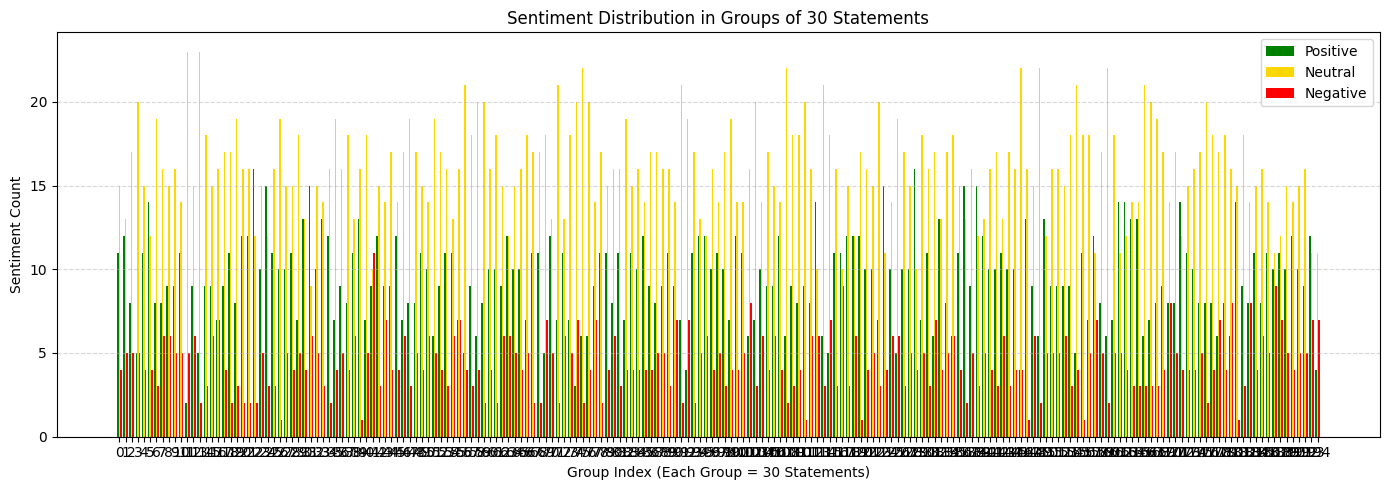

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load and clean
df = pd.read_csv('data.csv')
df.columns = df.columns.str.strip()

# Group every 30 statements
chunk_size = 30
chunks = [df[i:i+chunk_size] for i in range(0, len(df), chunk_size)]

# Count each sentiment in each chunk
positive_counts = []
neutral_counts = []
negative_counts = []

for chunk in chunks:
    sentiments = chunk['Sentiment'].str.strip().str.lower()
    positive_counts.append((sentiments == 'positive').sum())
    neutral_counts.append((sentiments == 'neutral').sum())
    negative_counts.append((sentiments == 'negative').sum())

# Setup plot
x = np.arange(len(positive_counts))  # one bar group per chunk
width = 0.25

plt.figure(figsize=(14, 5))

# Bars
plt.bar(x - width, positive_counts, width, label='Positive', color='green')
plt.bar(x,         neutral_counts, width, label='Neutral', color='gold')
plt.bar(x + width, negative_counts, width, label='Negative', color='red')

# Labels and style
plt.xlabel('Group Index (Each Group = 30 Statements)')
plt.ylabel('Sentiment Count')
plt.title('Sentiment Distribution in Groups of 30 Statements')
plt.xticks(x)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


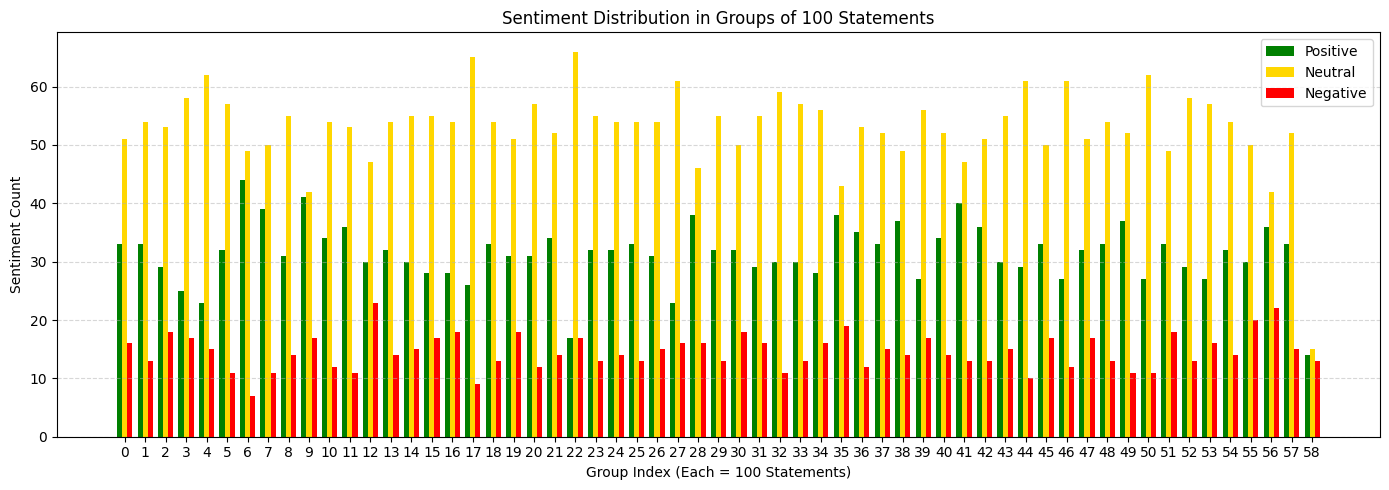

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load and clean
df = pd.read_csv('data.csv')
df.columns = df.columns.str.strip()

# Group every 100 statements
chunk_size = 100
chunks = [df[i:i+chunk_size] for i in range(0, len(df), chunk_size)]

# Count sentiments in each group
positive_counts = []
neutral_counts = []
negative_counts = []

for chunk in chunks:
    sentiments = chunk['Sentiment'].str.strip().str.lower()
    positive_counts.append((sentiments == 'positive').sum())
    neutral_counts.append((sentiments == 'neutral').sum())
    negative_counts.append((sentiments == 'negative').sum())

# Prepare plot
x = np.arange(len(positive_counts))  # one group per chunk
width = 0.25

plt.figure(figsize=(14, 5))

# Plot bars
plt.bar(x - width, positive_counts, width, label='Positive', color='green')
plt.bar(x,         neutral_counts, width, label='Neutral', color='gold')
plt.bar(x + width, negative_counts, width, label='Negative', color='red')

# Labels and styling
plt.xlabel('Group Index (Each = 100 Statements)')
plt.ylabel('Sentiment Count')
plt.title('Sentiment Distribution in Groups of 100 Statements')
plt.xticks(x)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


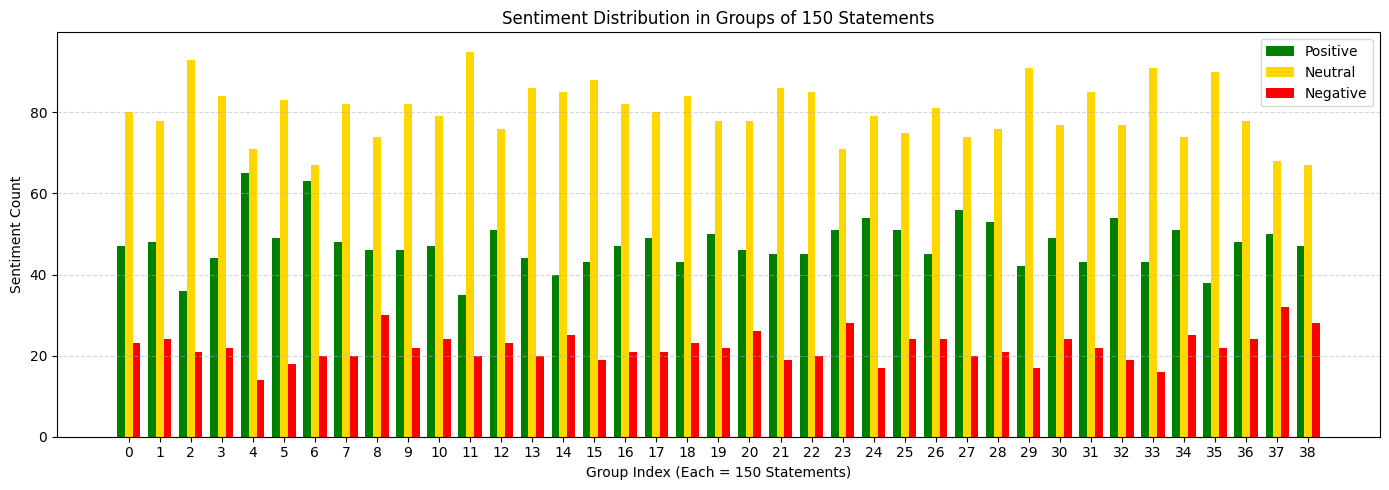

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load and clean
df = pd.read_csv('data.csv')
df.columns = df.columns.str.strip()

# Group every 150 statements
chunk_size = 150
chunks = [df[i:i+chunk_size] for i in range(0, len(df), chunk_size)]

# Count sentiments in each group
positive_counts = []
neutral_counts = []
negative_counts = []

for chunk in chunks:
    sentiments = chunk['Sentiment'].str.strip().str.lower()
    positive_counts.append((sentiments == 'positive').sum())
    neutral_counts.append((sentiments == 'neutral').sum())
    negative_counts.append((sentiments == 'negative').sum())

# Prepare plot
x = np.arange(len(positive_counts))  # one group per chunk
width = 0.25

plt.figure(figsize=(14, 5))

# Plot bars
plt.bar(x - width, positive_counts, width, label='Positive', color='green')
plt.bar(x,         neutral_counts, width, label='Neutral', color='gold')
plt.bar(x + width, negative_counts, width, label='Negative', color='red')

# Labels and styling
plt.xlabel('Group Index (Each = 150 Statements)')
plt.ylabel('Sentiment Count')
plt.title('Sentiment Distribution in Groups of 150 Statements')
plt.xticks(x)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


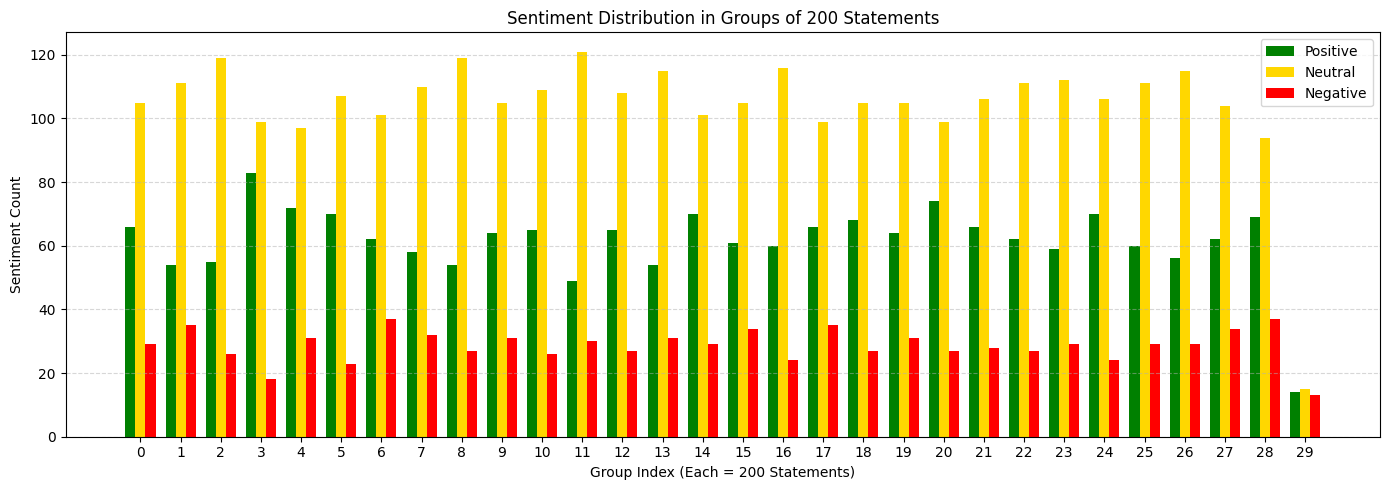

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load and clean
df = pd.read_csv('data.csv')
df.columns = df.columns.str.strip()

# Group every 200 statements
chunk_size = 200
chunks = [df[i:i+chunk_size] for i in range(0, len(df), chunk_size)]

# Count sentiments in each group
positive_counts = []
neutral_counts = []
negative_counts = []

for chunk in chunks:
    sentiments = chunk['Sentiment'].str.strip().str.lower()
    positive_counts.append((sentiments == 'positive').sum())
    neutral_counts.append((sentiments == 'neutral').sum())
    negative_counts.append((sentiments == 'negative').sum())

# Prepare plot
x = np.arange(len(positive_counts))  # one group per chunk
width = 0.25

plt.figure(figsize=(14, 5))

# Plot bars
plt.bar(x - width, positive_counts, width, label='Positive', color='green')
plt.bar(x,         neutral_counts, width, label='Neutral', color='gold')
plt.bar(x + width, negative_counts, width, label='Negative', color='red')

# Labels and styling
plt.xlabel('Group Index (Each = 200 Statements)')
plt.ylabel('Sentiment Count')
plt.title('Sentiment Distribution in Groups of 200 Statements')
plt.xticks(x)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
